<a href="https://colab.research.google.com/github/datafreak-adi/practice_ignore/blob/origin/Feature_selection(Task%2055).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## `Task` Select best features from from Wine Quality dataset.

* Data Link : https://www.kaggle.com/datasets/rajyellow46/wine-quality

* Drive link : https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv

Note : Follow approach from Feature Selection Session - 2

In [125]:
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures

In [126]:
# Your Code goes Here
wine_df = pd.read_csv("/content/winequalityN - winequalityN.csv")
wine_df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [127]:
from sklearn.preprocessing import LabelEncoder

lb= LabelEncoder()

wine_df["type"]= lb.fit_transform(wine_df['type'])


In [128]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   int64  
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [129]:
# Dealing with Null Values

for columns in wine_df.columns:

  max= wine_df[columns].max()
  min= wine_df[columns].min()


  #Generating random values into the column

  values =np.random.uniform(min, max, size= wine_df[columns].isnull().sum())

  # converting values generated to series

  random_series=pd.Series(values, index= wine_df[columns][wine_df[columns].isnull()].index)

  # Filling the generated random values

  wine_df.fillna({columns:random_series}, inplace= True)

In [130]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   int64  
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [131]:
wine_df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,1,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,1,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,1,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [132]:

wine_df.drop(columns= "type", inplace= True)
X= wine_df.iloc[: , : -1]
Y= wine_df.iloc[:, -1]

X_test, X_train, Y_test, Y_train= train_test_split(X,Y, test_size= 0.2, random_state= 42)

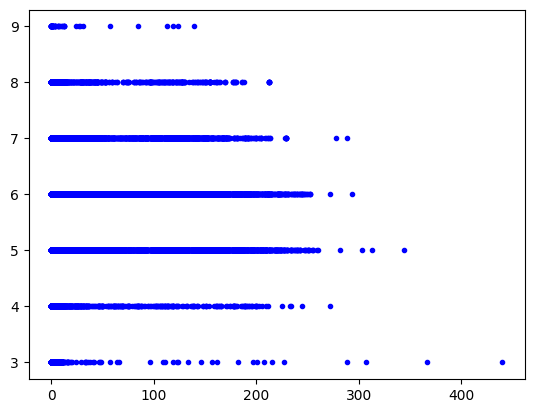

In [133]:
import matplotlib.pyplot as plt

plt.plot(X,Y, 'b.')

plt.show()

In [134]:
from sklearn.preprocessing import StandardScaler

sc= StandardScaler()

X_train= sc.fit_transform(X_train)
X_test= sc.fit_transform(X_test)

In [135]:
from sklearn.metrics import r2_score
lr= LinearRegression()

lr.fit(X_train,Y_train)

Y_pred= lr.predict(X_test)

r2_score(Y_test, Y_pred)

0.27081943431368793

In [136]:
wine_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.450000,8.8,6
1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.490000,9.5,6
2,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.440000,10.1,6
3,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.400000,9.9,6
4,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.400000,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.580000,10.5,5
6493,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.446789,11.2,6
6494,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.750000,11.0,6
6495,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.710000,10.2,5


In [137]:
!pip install --upgrade scikit-learn mlxtend

In [138]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
lr= LinearRegression()

ext= EFS(lr, max_features=11, scoring='r2',n_jobs=-1,cv=5)


In [139]:
sel= ext.fit(X_train, Y_train)

Features: 2047/2047

In [140]:
sel.best_score_

0.31527615225643546

In [141]:
sel.best_feature_names_

('1', '3', '5', '8', '10')